# **1. Download & Import Libraries**

In [1]:
import pandas as pd
import re
import ast
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


from pathlib import Path
from collections import Counter
from itertools import combinations
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### **NLTK**

In [2]:
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### **Sastrawi**

In [3]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [4]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

### **NER SpaCy Indonesia**

In [5]:
!pip install https://huggingface.co/asmud/ner-spacy-indonesian/resolve/main/id_ner_spacy_indonesian-1.1.0-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 38.1 MB/s eta 0:00:00


In [6]:
import spacy
nlp = spacy.load("id_ner_spacy_indonesian")

### **Pyvis**

In [7]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 88.5 MB/s eta 0:00:00


In [8]:
from pyvis.network import Network

# **2. Load Dataset**

In [9]:
df = pd.read_excel('/content/Pinjol-Korban.xlsx')
display(df.head())
print(f"\nJumlah data: {len(df)}")

,type,id,url,twitterUrl,text,source,retweetCount,replyCount,likeCount,quoteCount,...,card,place,entities,reply_to_user_results,quoted_tweet_results,quoted_tweet,retweeted_tweet,isConversationControlled,searchTermIndex,isQuote
0,tweet,2067881896047190512,https://x.com/leshugoo/status/2067881896047190512,https://twitter.com/leshugoo/status/2067881896...,"@indomyfess endingnyaa ginii nderrrr, udah mas...",NaN,0,0,0,0,...,NaN,{},{'media': [{'display_url': 'pic.x.com/1q3DEqvR...,NaN,NaN,NaN,NaN,False,0,NaN
1,tweet,2067876643549667514,https://x.com/luneofgod/status/206787664354966...,https://twitter.com/luneofgod/status/206787664...,@nucdue maksudnya galbay tu gmn kak?,NaN,0,0,0,0,...,NaN,{},{'user_mentions': [{'id_str': '199010914380250...,NaN,NaN,NaN,NaN,False,0,NaN
2,tweet,2067873348529365203,https://x.com/bl1ndnss/status/2067873348529365203,https://twitter.com/bl1ndnss/status/2067873348...,@karirfess kenapa indo ga maju² salah satunya ...,NaN,0,1,0,0,...,NaN,{},{'user_mentions': [{'id_str': '131484061937889...,NaN,NaN,NaN,NaN,False,0,NaN
3,tweet,2067872653965410486,https://x.com/karirfess/status/206787265396541...,https://twitter.com/karirfess/status/206787265...,"eh, ini lagi rame di threads\n\nini maksudnya ...",NaN,1,5,2,0,...,NaN,{},{'media': [{'allow_download_status': {'allow_d...,NaN,NaN,NaN,NaN,False,0,NaN
4,tweet,2067868084883616054,https://x.com/nodramakween/status/206786808488...,https://twitter.com/nodramakween/status/206786...,Anjing duid pajak gw buat ginian sialan orang ...,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,"{'type': 'tweet', 'id': '2067779667579572263',...",NaN,False,0,1.0



Jumlah data: 1538


# **3. Preprocessing**

### **Menghapus Tweet Duplikat**

In [10]:
# --- MENGHAPUS DUPLIKAT ---
# Hapus baris yang isi tweet-nya sama persis. keep='first' artinya simpan yang paling atas.
df = df.drop_duplicates(subset=['text'], keep='first')

# Reset index biar urutannya rapi lagi setelah ada baris yang dihapus
df = df.reset_index(drop=True)

display(df.head())

print(f"Jumlah data setelah duplikat dihapus: {len(df)}\n")

,type,id,url,twitterUrl,text,source,retweetCount,replyCount,likeCount,quoteCount,...,card,place,entities,reply_to_user_results,quoted_tweet_results,quoted_tweet,retweeted_tweet,isConversationControlled,searchTermIndex,isQuote
0,tweet,2067881896047190512,https://x.com/leshugoo/status/2067881896047190512,https://twitter.com/leshugoo/status/2067881896...,"@indomyfess endingnyaa ginii nderrrr, udah mas...",NaN,0,0,0,0,...,NaN,{},{'media': [{'display_url': 'pic.x.com/1q3DEqvR...,NaN,NaN,NaN,NaN,False,0,NaN
1,tweet,2067876643549667514,https://x.com/luneofgod/status/206787664354966...,https://twitter.com/luneofgod/status/206787664...,@nucdue maksudnya galbay tu gmn kak?,NaN,0,0,0,0,...,NaN,{},{'user_mentions': [{'id_str': '199010914380250...,NaN,NaN,NaN,NaN,False,0,NaN
2,tweet,2067873348529365203,https://x.com/bl1ndnss/status/2067873348529365203,https://twitter.com/bl1ndnss/status/2067873348...,@karirfess kenapa indo ga maju² salah satunya ...,NaN,0,1,0,0,...,NaN,{},{'user_mentions': [{'id_str': '131484061937889...,NaN,NaN,NaN,NaN,False,0,NaN
3,tweet,2067872653965410486,https://x.com/karirfess/status/206787265396541...,https://twitter.com/karirfess/status/206787265...,"eh, ini lagi rame di threads\n\nini maksudnya ...",NaN,1,5,2,0,...,NaN,{},{'media': [{'allow_download_status': {'allow_d...,NaN,NaN,NaN,NaN,False,0,NaN
4,tweet,2067868084883616054,https://x.com/nodramakween/status/206786808488...,https://twitter.com/nodramakween/status/206786...,Anjing duid pajak gw buat ginian sialan orang ...,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,"{'type': 'tweet', 'id': '2067779667579572263',...",NaN,False,0,1.0


Jumlah data setelah duplikat dihapus: 1514



### **Case Folding**

In [11]:
df['lower'] = df['text'].str.lower()
print('Case Folding Result : \n')

display(df[['text', 'lower']].head())

Case Folding Result : 



,text,lower
0,"@indomyfess endingnyaa ginii nderrrr, udah mas...","@indomyfess endingnyaa ginii nderrrr, udah mas..."
1,@nucdue maksudnya galbay tu gmn kak?,@nucdue maksudnya galbay tu gmn kak?
2,@karirfess kenapa indo ga maju² salah satunya ...,@karirfess kenapa indo ga maju² salah satunya ...
3,"eh, ini lagi rame di threads\n\nini maksudnya ...","eh, ini lagi rame di threads\n\nini maksudnya ..."
4,Anjing duid pajak gw buat ginian sialan orang ...,anjing duid pajak gw buat ginian sialan orang ...


### **Cleaning**

In [12]:
# =====================================================
# FUNGSI MEMBERSIHKAN TEKS UNTUK TOPIC MODELING
# =====================================================
def clean_text(content):
    if pd.isna(content):
        return ""
    content = str(content)
    # Hapus tag RT
    content = re.sub(r'^rt\s+@\w+:', ' ', content, flags=re.IGNORECASE)
    content = re.sub(r'\brt\b', ' ', content, flags=re.IGNORECASE)
    # Hapus URL
    content = re.sub(r'http\S+', '', content)
    # Hapus mention
    content = re.sub(r'@\w+', '', content)
    # Hapus karakter khusus dan emoji
    content = re.sub(r'[^a-zA-Z0-9\s]', '', content)
    # Hapus spasi berlebih
    content = re.sub(r'\s+', ' ', content).strip()
    return content


# =====================================================
# FUNGSI MENGAMBIL USERNAME DARI KOLOM AUTHOR
# =====================================================
def extract_username(author_data):
    try:
        data = ast.literal_eval(author_data)
        username = data.get('userName', '')
        return f'@{username}' if username else None

    except (ValueError, SyntaxError, TypeError):
        return None

# =====================================================
# PIPELINE PREPROCESSING
# =====================================================
# 1. Ambil username author
df['username'] = df['author'].apply(extract_username)
# 2. Ambil mention untuk Social Network Analysis
df['mentions_for_sna'] = df['lower'].apply(
    lambda x: ', '.join(re.findall(r'@\w+', str(x)))
    if pd.notna(x) else ''
)
# 3. Bersihkan teks untuk Topic Modeling
df['clean_text'] = df['lower'].apply(clean_text)

# =====================================================
# HASIL
# =====================================================
display(df[['username', 'mentions_for_sna', 'clean_text']].head())

,username,mentions_for_sna,clean_text
0,@leshugoo,@indomyfess,endingnyaa ginii nderrrr udah masuk your order...
1,@luneofgod,@nucdue,maksudnya galbay tu gmn kak
2,@bl1ndnss,@karirfess,kenapa indo ga maju salah satunya ga ada rasa ...
3,@karirfess,,eh ini lagi rame di threads ini maksudnya ada ...
4,@nodramakween,,anjing duid pajak gw buat ginian sialan orang ...


### **Tokenisasi**

In [13]:
# Fungsi tokenisasi NLTK
def nltk_tokenize(text):
    if not isinstance(text, str):
        return []
    return word_tokenize(text.lower())

# Menerapkan ke kolom awal
df['tokenized'] = df['clean_text'].apply(nltk_tokenize)


display(df[['clean_text', 'tokenized']].head(5))

,clean_text,tokenized
0,endingnyaa ginii nderrrr udah masuk your order...,"[endingnyaa, ginii, nderrrr, udah, masuk, your..."
1,maksudnya galbay tu gmn kak,"[maksudnya, galbay, tu, gmn, kak]"
2,kenapa indo ga maju salah satunya ga ada rasa ...,"[kenapa, indo, ga, maju, salah, satunya, ga, a..."
3,eh ini lagi rame di threads ini maksudnya ada ...,"[eh, ini, lagi, rame, di, threads, ini, maksud..."
4,anjing duid pajak gw buat ginian sialan orang ...,"[anjing, duid, pajak, gw, buat, ginian, sialan..."


### **Normalisasi**

In [14]:
# KAMUS DARI CSV
df_norm = pd.read_csv('/content/slang.csv')
kamus_csv = pd.Series(df_norm['formal'].values, index=df_norm['slang']).to_dict()

# KAMUS MANUAL
kamus_manual = {
    # Kata ganti orang
    "gw": "saya",
    "gua": "saya",
    "gue": "saya",
    "sy": "saya",
    "aku": "saya",
    "ane": "saya",

    # Orang tua
    "ortu": "orang tua",
    "bokap": "ayah",
    "nyokap": "ibu",

    # Negasi
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "engga": "tidak",
    "enggak": "tidak",
    "tak": "tidak",

    # Kata sambung dan umum
    "yg": "yang",
    "dgn": "dengan",
    "dr": "dari",
    "krn": "karena",
    "karna": "karena",
    "karnaa": "karena",
    "udh": "sudah",
    "sdh": "sudah",
    "blm": "belum",
    "trs": "terus",
    "trus": "terus",
    "tp": "tetapi",
    "tpi": "tetapi",
    "jd": "jadi",
    "jdnya": "jadinya",

    # Kata kerja
    "ngambil": "mengambil",
    "ngasih": "memberi",
    "ngasi": "memberi",
    "ngelihat": "melihat",
    "ngeliat": "melihat",
    "ngikut": "mengikuti",
    "ngurus": "mengurus",
    "ngutang": "berutang",
    "ngutangin": "meminjamkan",

    # Uang
    "duit": "uang",
    "cuan": "keuntungan",

    # Keluarga
    "adikku": "adik",
    "kakakku": "kakak",
    "suamiku": "suami",
    "istriku": "istri",

    # Intensitas
    "banget": "sangat",
    "bgt": "sangat",
    "bgtt": "sangat",
    "parahhh": "parah",

    # Emosi
    "sedihh": "sedih",
    "kecewaaa": "kecewa",
    "marahhh": "marah",

    # Bahasa media sosial
    "dm": "pesan",
    "pm": "pesan",
    "chat": "pesan",
    "wa": "whatsapp",
    "vc": "video call",

    # Singkatan umum
    "dll": "dan lain lain",
    "dsb": "dan sebagainya"
}

kamus_manual2 = {
    # Slang Twitter Umum
    "bgt": "banget", "tp": "tapi", "yg": "yang", "jd": "jadi",
    "emg": "memang", "gak": "tidak", "gk": "tidak", "ga": "tidak",
    "rep": "balas", "nder": "pengirim", "twt": "cuitan", "gw": "aku",
    "lu": "kamu", "kalo": "kalau", "krn": "karena", "dgn": "dengan",

    # Istilah Khas Korban Pinjol
    "galbay": "gagal bayar",
    "sebar data": "sebar data", # biar nggak kepisah
    "dc": "penagih utang", # debt collector
    "apk": "aplikasi",
    "diteror": "teror",
    "diancam": "ancam",
    "penipu": "tipu",
    "pinjol": "pinjaman online",
    "paylater": "pinjaman",
    "dc": "debt collector",
    "galbay": "gagal bayar",

    # Istilah Khas Bot / Promosi Pinjol
    "acc": "terima", # pasti acc -> pasti terima
    "gestun": "gesek tunai",
    "joki": "jasa",
    "limit": "batas",
    "cair": "pencairan",
    "ktp": "kartu tanda penduduk",
    "tf": "transfer",
    "dm": "pesan",
    "pm": "pesan"
}

# Menggabungkan Kamus dari CSV dan Kamus Manual
kamus_gabungan = {}
kamus_gabungan.update(kamus_csv)
kamus_gabungan.update(kamus_manual)
kamus_gabungan.update(kamus_manual2)

# Total Kata pada Kamus
print(f"Total kata di kamus gabungan sekarang: {len(kamus_gabungan)} kata")

# -------------------------------------------

# Menerapkan Fungsi Normalisasi
def eksekusi_normalisasi(list_kata):
    if not isinstance(list_kata, list):
        return []

    kata_normal = []
    for kata in list_kata:
      teks_bersih = re.sub(r'(.)\1{2,}', r'\1', str(kata))
      kata_akhir = kamus_gabungan.get(teks_bersih, teks_bersih)
      kata_normal.append(kata_akhir)

    return kata_normal

df['normalized'] = df['tokenized'].apply(eksekusi_normalisasi)

# Menampilkan teks sebelum dan sudah di Normalisasi
display(df[['tokenized', 'normalized']].head())

Total kata di kamus gabungan sekarang: 1526 kata


,tokenized,normalized
0,"[endingnyaa, ginii, nderrrr, udah, masuk, your...","[endingnyaa, begini, pengirim, sudah, masuk, y..."
1,"[maksudnya, galbay, tu, gmn, kak]","[maksudnya, gagal bayar, itu, bagaimana, kakak]"
2,"[kenapa, indo, ga, maju, salah, satunya, ga, a...","[kenapa, indonesia, tidak, maju, salah, satuny..."
3,"[eh, ini, lagi, rame, di, threads, ini, maksud...","[eh, ini, lagi, rame, di, threads, ini, maksud..."
4,"[anjing, duid, pajak, gw, buat, ginian, sialan...","[anjing, uang, pajak, aku, buat, ginian, siala..."


### **Stop Word**

In [15]:
# Mengambil kata-kata stopword dari NLTK
stop_nltk = set(stopwords.words('indonesian'))

# Mengambil kata-kata stopword dari file
try:
    df_stop_csv = pd.read_csv('/content/stopwordbahasa.csv', header=None, names=['kata_stop'])
    stop_csv = set(df_stop_csv['kata_stop'].dropna().tolist())
except:
    stop_csv = set()

# Menambahkan kata-kata stopword secara manual
stop_manual = {
    'nya', 'sih', 'tuh', 'dong', 'deh', 'loh', 'kan', 'kok', 'lah', 'buat',
    'nder', 'rep', 'twt', 'aja', 'saja', 'ya', 'yang', 'sih', 'pas', 'mah'
}

# Menggabungkan base NLTK, CSV, dan Manual
stop_words_gabungan = stop_nltk.union(stop_csv).union(stop_manual)


# CONTEXT-AWARE
kata_negasi = {'tidak', 'bukan', 'belum', 'jangan', 'kurang'}
stop_words_final = stop_words_gabungan - kata_negasi

print(f"Total Stopword siap pakai: {len(stop_words_final)} kata")

def hapus_stopword(list_kata):
    if not isinstance(list_kata, list):
        return []

    kata_bersih = [kata for kata in list_kata if kata not in stop_words_final]
    return kata_bersih

df['stopword_removed'] = df['normalized'].apply(hapus_stopword)

# Menampilkan teks sebelum dan sesudah Stop Word
display(df[['normalized', 'stopword_removed']].head())

Total Stopword siap pakai: 764 kata


,normalized,stopword_removed
0,"[endingnyaa, begini, pengirim, sudah, masuk, y...","[endingnyaa, pengirim, masuk, your, order, ter..."
1,"[maksudnya, gagal bayar, itu, bagaimana, kakak]","[maksudnya, gagal bayar, kakak]"
2,"[kenapa, indonesia, tidak, maju, salah, satuny...","[indonesia, tidak, maju, salah, satunya, tidak..."
3,"[eh, ini, lagi, rame, di, threads, ini, maksud...","[eh, rame, threads, maksudnya, orang2, sengaja..."
4,"[anjing, uang, pajak, aku, buat, ginian, siala...","[anjing, uang, pajak, ginian, sialan, orang, o..."


### **Stemming**

In [16]:
tqdm.pandas()

factory = StemmerFactory()
stemmer = factory.create_stemmer()

term_dict = {}
for document in df['stopword_removed']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = " "

print(f"Total kata unik yang perlu di-stemming: {len(term_dict)} kata.")

# Progress bar
print("\nMulai stemming kata unik:")
for term in tqdm(term_dict):
    term_dict[term] = stemmer.stem(term)

def get_stemmed_term(document):
    return " ".join([term_dict[term] for term in document])

df['stemmed'] = df['stopword_removed'].apply(get_stemmed_term)

# Menampilkan teks sebelum dan sudah di Stemming
display(df[['stopword_removed', 'stemmed']].head())

Total kata unik yang perlu di-stemming: 9638 kata.

Mulai stemming kata unik:


100%|██████████| 9638/9638 [12:16<00:00, 13.09it/s]


,stopword_removed,stemmed
0,"[endingnyaa, pengirim, masuk, your, order, ter...",endingnyaa kirim masuk your order ternyataa si...
1,"[maksudnya, gagal bayar, kakak]",maksud gagal bayar kakak
2,"[indonesia, tidak, maju, salah, satunya, tidak...",indonesia tidak maju salah satu tidak tanggung...
3,"[eh, rame, threads, maksudnya, orang2, sengaja...",eh rame threads maksud orang2 sengaja gagal ba...
4,"[anjing, uang, pajak, ginian, sialan, orang, o...",anjing uang pajak ginian sial orang orang mend...


### **Hasil dari Preprocessing**

In [17]:
display(df[['username', 'mentions_for_sna', 'text', 'stemmed']].head())

,username,mentions_for_sna,text,stemmed
0,@leshugoo,@indomyfess,"@indomyfess endingnyaa ginii nderrrr, udah mas...",endingnyaa kirim masuk your order ternyataa si...
1,@luneofgod,@nucdue,@nucdue maksudnya galbay tu gmn kak?,maksud gagal bayar kakak
2,@bl1ndnss,@karirfess,@karirfess kenapa indo ga maju² salah satunya ...,indonesia tidak maju salah satu tidak tanggung...
3,@karirfess,,"eh, ini lagi rame di threads\n\nini maksudnya ...",eh rame threads maksud orang2 sengaja gagal ba...
4,@nodramakween,,Anjing duid pajak gw buat ginian sialan orang ...,anjing uang pajak ginian sial orang orang mend...


### **Simpan ke dalam Excel dan CSV**

In [18]:
df.to_excel("pinjol-korban_Preprocessing.xlsx", index=False)

In [19]:
df.to_csv("pinjol-korban_Preprocessing.csv", index=False)

# **4. Frequent Term-Based Text Clustering (FTC)**

In [21]:
def determine_frequent_termsets(documents, minsup):
    """
    Tahap awal: Mencari frequent termsets (kombinasi kata)
    yang kemunculannya >= minsup (dalam bentuk persentase/float).
    """
    n_docs = len(documents)
    min_count = minsup * n_docs

    # Ekstrak semua token kata unik per dokumen
    doc_words = [set(doc.split()) for doc in documents if pd.notna(doc) and doc.strip() != ""]

    # Hitung frekuensi tiap kata tunggal dulu
    word_counts = Counter()
    for words in doc_words:
        word_counts.update(words)

    frequent_words = {word for word, count in word_counts.items() if count >= min_count}

    # Bangun termsets (bisa kombinasi 1 kata, 2 kata, dst.)
    frequent_termsets = {}

    # Untuk simplisitas & efisiensi UAS (1-gram dan 2-gram frequent itemsets)
    # 1-Word Termsets
    for word in frequent_words:
        termset = frozenset([word])
        # Hitung coverage (dokumen mana saja yang mengandung kata ini)
        coverage = {i for i, words in enumerate(doc_words) if termset.issubset(words)}
        frequent_termsets[termset] = coverage

    # 2-Word Termsets
    for w1, w2 in combinations(frequent_words, 2):
        termset = frozenset([w1, w2])
        coverage = {i for i, words in enumerate(doc_words) if termset.issubset(words)}
        if len(coverage) >= min_count:
            frequent_termsets[termset] = coverage

    return frequent_termsets

def calculate_overlap(target_set, remaining_termsets):
    # target_coverage adalah C_i (himpunan dokumen yang dicover oleh termset kandidat)
    target_coverage = remaining_termsets[target_set]

    # Guard clause, kalau len() dokumen kosong, otomatis overlap 0
    if len(target_coverage) == 0:
        return 0.0

    entropy_overlap = 0.0

    # Iterasi untuk setiap dokumen D_j di dalam klaster C_i
    for doc in target_coverage:
        # Menghitung f_j: frekuensi kemunculan dokumen pada keseluruhan remaining_termsets
        f_j = len([coverage for coverage in remaining_termsets.values() if doc in coverage])

        if f_j > 0:
            p_j = 1.0 / f_j
            entropy_overlap += (-p_j * math.log(p_j))

    return entropy_overlap

def ftc_topic_modeling(df_column, minsup=0.05):
    """
    Implementasi murni Pseudokode FTC dari Jurnal.
    D = list dokumen dari df['stemmed']
    minsup = minimal support (float, contoh 0.05 artinya minimal muncul di 5% data)
    """
    # Inisialisasi Database D dan ukuran n
    D = [doc for doc in df_column.tolist() if pd.notna(doc)]
    n = len(D)

    # SelectedTermSets := {};
    selected_termsets = {}

    # RemainingTermSets := DetermineFrequentTermsets(D, minsup);
    remaining_termsets = determine_frequent_termsets(D, minsup)

    # Set pelacak dokumen yang sudah tercover
    covered_all_docs = set()

    # while |cov(SelectedTermSets)| != n do
    while len(covered_all_docs) < n and len(remaining_termsets) > 0:

        best_candidate = None
        min_overlap = float('inf')

        # for each set in RemainingTermSets do
        for termset in list(remaining_termsets.keys()):
            # Calculate overlap for set;
            overlap = calculate_overlap(termset, remaining_termsets)

            # BestCandidate := element of RemainingTermSets with minimum overlap;
            if overlap < min_overlap:
                min_overlap = overlap
                best_candidate = termset

        if best_candidate is None:
            break

        # SelectedTermSets := SelectedTermSets U {BestCandidate};
        # selected_termsets[best_candidate] = remaining_termsets[best_candidate]
        # Simpan coverage + FTC score
        selected_termsets[best_candidate] = {
            'coverage': remaining_termsets[best_candidate],
            'ftc_score': min_overlap
        }

        # Ambil indeks dokumen yang dicover oleh BestCandidate
        # best_coverage = remaining_termsets[best_candidate]
        # covered_all_docs.update(best_coverage)
        best_coverage = selected_termsets[best_candidate]['coverage']
        covered_all_docs.update(best_coverage)

        # Remove all documents in cov(BestCandidate) from D and from the coverage
        del remaining_termsets[best_candidate]

        updated_remaining = {}
        for termset, coverage in remaining_termsets.items():
            new_coverage = coverage.difference(best_coverage)
            # Jika termset tersebut masih menaungi dokumen yang tersisa, simpan
            if len(new_coverage) > 0:
                updated_remaining[termset] = new_coverage

        remaining_termsets = updated_remaining

    # return SelectedTermSets and the cover of the elements;
    return selected_termsets

# minsup=0.05 artinya sebuah topik minimal harus muncul di 5% dari total 2500 data
hasil_topik = ftc_topic_modeling(df['stemmed'], minsup=0.05)

# Tampilkan hasil klastering topik ke layar
print("=== HASIL TOPIC MODELING (FTC) ===")
for i, (termset, info) in enumerate(hasil_topik.items()):
    nama_topik = ", ".join(list(termset))
    print(
        f"Topik {i+1} "
        f"(Frequent Terms: [{nama_topik}]): "
        f"Meng-cover {len(info['coverage'])} dokumen "
        f"| FTC Score = {info['ftc_score']}"
    )

=== HASIL TOPIC MODELING (FTC) ===
Topik 1 (Frequent Terms: [online, uang]): Meng-cover 80 dokumen | FTC Score = 13.066431191211114
Topik 2 (Frequent Terms: [uang, pinjam]): Meng-cover 19 dokumen | FTC Score = 3.0229449637497097
Topik 3 (Frequent Terms: [tidak, uang]): Meng-cover 56 dokumen | FTC Score = 10.313031208233317
Topik 4 (Frequent Terms: [bayar, uang]): Meng-cover 22 dokumen | FTC Score = 5.811028458234447
Topik 5 (Frequent Terms: [uang]): Meng-cover 1 dokumen | FTC Score = 0.34657359027997264
Topik 6 (Frequent Terms: [tidak, utang]): Meng-cover 45 dokumen | FTC Score = 7.89094548918964
Topik 7 (Frequent Terms: [utang, gagal]): Meng-cover 26 dokumen | FTC Score = 6.402756297733239
Topik 8 (Frequent Terms: [bayar, utang]): Meng-cover 11 dokumen | FTC Score = 2.081044271368607
Topik 9 (Frequent Terms: [utang]): Meng-cover 10 dokumen | FTC Score = 2.4153687260913634
Topik 10 (Frequent Terms: [bukan, gagal]): Meng-cover 41 dokumen | FTC Score = 8.67866568945982
Topik 11 (Frequent

In [23]:
# 1. Definisikan stopwords
kata_pasaran_ftc = [
    'tidak','bayar','gagal','orang','iya','gitu','gimana',
    'bukan','pakai','lain','dan','di','yang','buat',
    'ada','ini','itu','udah','dari','kalau','aja',
    'sama','aku', 'kakak'
]

# 2. Membuat kolom FTC yang bersih dari stopword dan angka/huruf pendek
df['stemmed_ftc'] = df['stemmed'].apply(
    lambda x: ' '.join([
        word
        for word in str(x).split()
        if word not in kata_pasaran_ftc
        and len(word) > 2
    ])
)

# 3. Memanggil FTC dengan kolom yang sudah difilter
hasil_topik = ftc_topic_modeling(df['stemmed_ftc'], minsup=0.05)

# 4. Memastikan D berisi list dokumen yang persis sama dengan yang masuk ke fungsi FTC
D = [doc for doc in df['stemmed'].tolist() if pd.notna(doc)]

# 5. Print Hasil
print("="*70)
print("HASIL TOPIC MODELING FTC (SETELAH FILTER)")
print("="*70)

for i, (termset, info) in enumerate(hasil_topik.items()):
    nama_topik = ", ".join(list(termset))
    coverage_indices = list(info['coverage']) # Mengambil list index dokumen

    print(f"\nTopik {i+1} (Frequent Terms: [{nama_topik}])")
    print(f"Total Meng-cover {len(coverage_indices)} dokumen | FTC Score = {info['ftc_score']}")
    print("Daftar Keseluruhan Dokumen yang Terkover:")

    # Hapus [:5] biar semua isi list diiterasi sampai habis
    for idx in coverage_indices:
        print(f"   -> [Doc Index {idx}]: {D[idx]}")

HASIL TOPIC MODELING FTC (SETELAH FILTER)

Topik 1 (Frequent Terms: [korban, ilegal])
Total Meng-cover 81 dokumen | FTC Score = 15.964762676681406
Daftar Keseluruhan Dokumen yang Terkover:
   -> [Doc Index 1025]: korban pinjam online jebak 46 pinjam online ilegal pakai rela data kantor dan lain lain bantu gagal bayar aman backup cloning aplikasi gagal bayar aman sebar data kekontakedso kantor bunda tiara solusi kawal tuntas pinjam online nedtur pinjamanonline memecoin msdhoni
   -> [Doc Index 1031]: puluh cari kerja korban pinjam online jaktim rugi rp1 m
   -> [Doc Index 1054]: korban pinjam online jebak 42 aplikasi tahu keluarga tuntas habis uang pribadi gagal bayar pinjam online aman sebar data kawal konsultasi bunda tiara whatsapp 081536624308 pinjam online korbanpinjol galbaypinjol jokipinjol
   -> [Doc Index 1057]: korban pinjam online tidak kasih bansos
   -> [Doc Index 1073]: korban korban pinjam online ilegal judol nama laku mustinya kena pasal judi
   -> [Doc Index 1074]: piki

# **5. Topic Modeling (LDA)**

In [24]:
print("="*50)
print("MEMULAI TOPIC MODELING (LDA)")
print("="*50)

# 1. Hapus data kosong
df_lda = df.copy()
df_lda = df_lda[df_lda['stemmed'].notna()]

# 2. Stopword khusus domain pinjol
kata_pasaran = [
    'tidak','bayar','gagal','orang','iya','gitu','gimana',
    'bukan','pakai','lain','dan','di','yang','buat',
    'ada','ini','itu','udah','dari','kalau','aja',
    'sama','aku'
]

# 3. Vectorization
vectorizer_lda = CountVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=1000,
    stop_words=kata_pasaran
)

X_lda = vectorizer_lda.fit_transform(
    df_lda['stemmed'].fillna('')
)

# 4. Membuat model LDA
n_topics = 5

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

print(f"[INFO] Melatih model LDA dengan {n_topics} topik...\n")

lda_model.fit(X_lda)

# 5. Fungsi menampilkan topik
def tampilkan_topik(model, feature_names, no_top_words=10):
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-no_top_words-1:-1]
        top_words = [feature_names[i] for i in top_idx]

        print(f"Topik {idx+1}")
        print(" | ".join(top_words))
        print("-"*50)

# 6. Tampilkan hasil
feature_names = vectorizer_lda.get_feature_names_out()
tampilkan_topik(lda_model, feature_names)

MEMULAI TOPIC MODELING (LDA)
[INFO] Melatih model LDA dengan 5 topik...

Topik 1
bpjs | uang | rumah | bank | anak | gaji | tagih | dana | sehat | tarik
--------------------------------------------------
Topik 2
utang | uang | kredit | bunga | perintah | bank | rupiah | ekonomi | usaha | lemah
--------------------------------------------------
Topik 3
lapor | teman | triliun | polri | bpjs | biaya | terima | sehat | dukung | selamat
--------------------------------------------------
Topik 4
pinjam | online | kakak | aplikasi | debt | telbay | jangan | collector | kerja | teror
--------------------------------------------------
Topik 5
pinjam | online | korban | teror | ilegal | data | ojk | bunuh | daring | judol
--------------------------------------------------



1. MENCARI K OPTIMAL DENGAN ELBOW PERPLEXITY
Testing K=2...
Testing K=3...
Testing K=4...
Testing K=5...
Testing K=6...
Testing K=7...
Testing K=8...
Testing K=9...
Testing K=10...


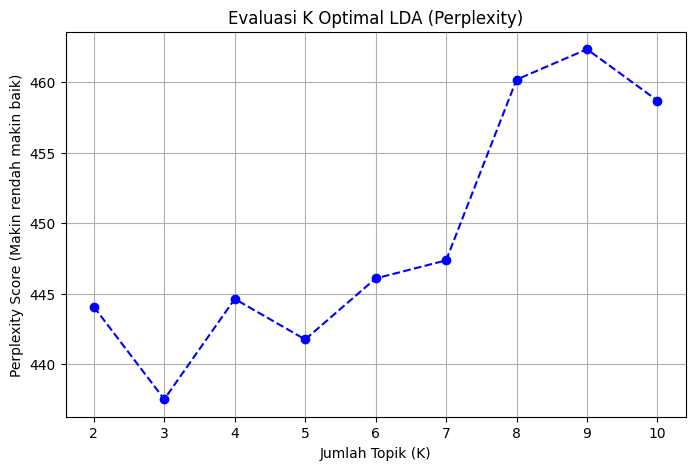


2. FIT MODEL LDA FINAL DENGAN K=3
Topik 1: Teror Debt Collector & Korban Pinjol
pinjam, online, korban, teror, kakak, aplikasi, data, debt, uang, collector

Topik 2: Utang, Kredit & Kondisi Ekonomi
utang, uang, bank, bunga, kredit, perintah, rupiah, indonesia, ekonomi, negara

Topik 3: Pelaporan Pinjol Ilegal & Dampak Sosial
bpjs, lapor, teman, sehat, rp, polri, korban, triliun, terima, ilegal


3. ASSIGN TOPIK KE DATAFRAME
Berhasil nge-assign topik! Berikut sampel hasilnya:


,username,stemmed,label_topik_lda,probabilitas_topik
0,@leshugoo,endingnyaa kirim masuk your order ternyataa si...,"Topik 2: Utang, Kredit & Kondisi Ekonomi",0.850318
1,@luneofgod,maksud gagal bayar kakak,Topik 1: Teror Debt Collector & Korban Pinjol,0.661460
2,@bl1ndnss,indonesia tidak maju salah satu tidak tanggung...,Topik 1: Teror Debt Collector & Korban Pinjol,0.738634
3,@karirfess,eh rame threads maksud orang2 sengaja gagal ba...,Topik 1: Teror Debt Collector & Korban Pinjol,0.915152
4,@nodramakween,anjing uang pajak ginian sial orang orang mend...,Topik 1: Teror Debt Collector & Korban Pinjol,0.505505


In [25]:
# ==========================================
# 1. MENCARI K OPTIMAL DENGAN ELBOW PERPLEXITY
# ==========================================
print("\n" + "="*50)
print("1. MENCARI K OPTIMAL DENGAN ELBOW PERPLEXITY")
print("="*50)

K_range = range(2, 11)
perplexities = []

for k in K_range:
    print(f"Testing K={k}...")
    lda_temp = LatentDirichletAllocation(n_components=k, random_state=42)
    lda_temp.fit(X_lda)
    # Perplexity makin rendah semakin bagus
    perplexities.append(lda_temp.perplexity(X_lda))

# Plot hasil Perplexity
plt.figure(figsize=(8, 5))
plt.plot(K_range, perplexities, marker='o', linestyle='--', color='b')
plt.title('Evaluasi K Optimal LDA (Perplexity)')
plt.xlabel('Jumlah Topik (K)')
plt.ylabel('Perplexity Score (Makin rendah makin baik)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# ==========================================
# 2. FIT MODEL LDA FINAL
# ==========================================
optimal_k = 3

print("\n" + "="*50)
print(f"2. FIT MODEL LDA FINAL DENGAN K={optimal_k}")
print("="*50)

lda_final = LatentDirichletAllocation(n_components=optimal_k, random_state=42)
lda_final.fit(X_lda)

label_dict = {
    0: "Topik 1: Teror Debt Collector & Korban Pinjol",
    1: "Topik 2: Utang, Kredit & Kondisi Ekonomi",
    2: "Topik 3: Pelaporan Pinjol Ilegal & Dampak Sosial"
}

feature_names = vectorizer_lda.get_feature_names_out()
for idx, topic in enumerate(lda_final.components_):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]

    print(f"{label_dict[idx]}")
    print(", ".join(top_words))
    print()

# ==========================================
# 3. ASSIGN TOPIK KE SETIAP TWEET & LABELING
# ==========================================
print("\n" + "="*50)
print("3. ASSIGN TOPIK KE DATAFRAME")
print("="*50)

# Dapatkan probabilitas setiap dokumen terhadap semua topik
topic_probabilities = lda_final.transform(X_lda)

# Ambil index topik dengan probabilitas paling tinggi untuk setiap tweet
dominant_topics = topic_probabilities.argmax(axis=1)

# Masukan hasilnya ke DataFrame
df_lda['id_topik_lda'] = dominant_topics
df_lda['label_topik_lda'] = df_lda['id_topik_lda'].map(label_dict)
df_lda['probabilitas_topik'] = topic_probabilities.max(axis=1)


print("Berhasil nge-assign topik! Berikut sampel hasilnya:")
display(df_lda[['username', 'stemmed', 'label_topik_lda', 'probabilitas_topik']].head())

# **6. SNA**

🟠 Orange = akun yang melakukan mention (source node)


🟢 Hijau/Tosca = akun yang hanya menerima mention (target node)

In [26]:
# ==========================================
# SOCIAL NETWORK ANALYSIS (SNA)
# ==========================================
print("="*60)
print("MEMULAI SOCIAL NETWORK ANALYSIS")
print("="*60)

# =====================================================
# 1. COPY DATASET
# =====================================================
df_sna = df.copy()

# =====================================================
# 2. MEMBERSIHKAN USERNAME
# =====================================================
df_sna['source_user'] = (
    df_sna['username']
    .astype(str)
    .str.replace('@','', regex=False)
    .str.strip()
    .str.lower()
)

# =====================================================
# 3. EKSTRAK MENTION
# =====================================================
def extract_mentions(x):

    if pd.isna(x):
        return []

    mentions = re.findall(r'@\w+', str(x))

    return [
        mention.replace('@','').lower()
        for mention in mentions
    ]

df_sna['target_users_list'] = (
    df_sna['mentions_for_sna']
    .apply(extract_mentions)
)

print("[INFO] Ekstraksi mention selesai")

# =====================================================
# 4. MEMBUAT EDGE LIST
# =====================================================
edge_df = df_sna.explode('target_users_list')

edge_df = edge_df.rename(
    columns={
        'target_users_list':'target_user'
    }
)

# hapus kosong
edge_df = edge_df.dropna(
    subset=['source_user','target_user']
)

edge_df = edge_df[
    edge_df['target_user'] != ''
]

# hapus self-loop
edge_df = edge_df[
    edge_df['source_user'] != edge_df['target_user']
]

print(f"[INFO] Jumlah relasi: {len(edge_df)}")

# =====================================================
# 5. MEMBANGUN GRAPH
# =====================================================
G = nx.from_pandas_edgelist(
    edge_df,
    source='source_user',
    target='target_user',
    create_using=nx.DiGraph()
)

print(f"[INFO] Jumlah node : {G.number_of_nodes()}")
print(f"[INFO] Jumlah edge : {G.number_of_edges()}")

# =====================================================
# 6. CENTRALITY
# =====================================================
print("\nMenghitung centrality...")

degree_cent = nx.degree_centrality(G)

indegree_cent = nx.in_degree_centrality(G)

outdegree_cent = nx.out_degree_centrality(G)

betweenness_cent = nx.betweenness_centrality(
    G
)

nx.set_node_attributes(
    G,
    degree_cent,
    'degree'
)

nx.set_node_attributes(
    G,
    indegree_cent,
    'indegree'
)

nx.set_node_attributes(
    G,
    outdegree_cent,
    'outdegree'
)

nx.set_node_attributes(
    G,
    betweenness_cent,
    'betweenness'
)

# =====================================================
# 7. TOP ACCOUNT PALING SERING DISEBUT
# =====================================================
print("\n")
print("="*60)
print("TOP 10 ACCOUNT PALING SERING DI-MENTION")
print("="*60)

top_indegree = sorted(
    indegree_cent.items(),
    key=lambda x:x[1],
    reverse=True
)[:10]

for akun,score in top_indegree:
    print(
        f"@{akun:<25} {score:.4f}"
    )

# =====================================================
# 8. TOP ACCOUNT PALING AKTIF MENTION
# =====================================================
print("\n")
print("="*60)
print("TOP 10 ACCOUNT PALING AKTIF MENTION")
print("="*60)

top_outdegree = sorted(
    outdegree_cent.items(),
    key=lambda x:x[1],
    reverse=True
)[:10]

for akun,score in top_outdegree:
    print(
        f"@{akun:<25} {score:.4f}"
    )

# =====================================================
# 10. EXPORT GEXF UNTUK GEPHI
# =====================================================
nx.write_gexf(
    G,
    "jaringan_mentions.gexf"
)

print("\n[SUKSES] jaringan_mentions.gexf tersimpan")

# =====================================================
# 11. VISUALISASI INTERAKTIF PYVIS
# =====================================================
print("\nMembuat visualisasi PyVis...")

net = Network(
    notebook=True,
    directed=True,
    height="800px",
    width="100%",
    bgcolor="#1e1e1e",
    font_color="white"
)

# akun yang melakukan mention
source_accounts = set(
    edge_df['source_user']
)

# tambah node
for node in G.nodes():

    size = (
        indegree_cent.get(node,0)*4000
        + 15
    )

    if node in source_accounts:
        color = "#FFC300"
        label = f"[SOURCE] @{node}"
    else:
        color = "#1ABC9C"
        label = f"@{node}"

    net.add_node(
        node,
        label=label,
        size=size,
        color=color,
        title=
        f"""
        Username : @{node}<br>
        Degree : {degree_cent.get(node,0):.4f}<br>
        InDegree : {indegree_cent.get(node,0):.4f}<br>
        OutDegree : {outdegree_cent.get(node,0):.4f}<br>
        Betweenness : {betweenness_cent.get(node,0):.4f}
        """
    )

# tambah edge
for _,row in edge_df.iterrows():

    net.add_edge(
        row['source_user'],
        row['target_user'],
        color="#666666",
        width=1
    )

# physics
net.barnes_hut()

# simpan html
net.show(
    "visualisasi_sna.html"
)

print("[SUKSES] visualisasi_sna.html tersimpan")

# =====================================================
# 12. RINGKASAN
# =====================================================
print("\n")
print("="*60)
print("RINGKASAN JARINGAN")
print("="*60)

print(
    "Jumlah Node :",
    G.number_of_nodes()
)

print(
    "Jumlah Edge :",
    G.number_of_edges()
)

print(
    "Density :",
    nx.density(G)
)

print(
    "Connected Component :",
    nx.number_weakly_connected_components(G)
)

print("\nSELESAI")

MEMULAI SOCIAL NETWORK ANALYSIS
[INFO] Ekstraksi mention selesai
[INFO] Jumlah relasi: 1197
[INFO] Jumlah node : 1283
[INFO] Jumlah edge : 1124

Menghitung centrality...


TOP 10 ACCOUNT PALING SERING DI-MENTION
@ojkindonesia              0.0187
@prabowo                   0.0156
@tanyakanrl                0.0156
@karirfess                 0.0133
@mrtweepsid                0.0125
@unmagnetism               0.0125
@tanyarlfes                0.0109
@lambesahamjja             0.0109
@kapuds640                 0.0078
@kompascom                 0.0078


TOP 10 ACCOUNT PALING AKTIF MENTION
@belengbeleng687           0.0374
@divhumas_polri            0.0234
@mrtweepsid                0.0156
@r_kapau                   0.0125
@pradaprasetya21           0.0109
@nazarethze                0.0094
@temanduit                 0.0086
@mfadillubis               0.0078
@daysafteryouu             0.0070
@mangunsong63              0.0070

[SUKSES] jaringan_mentions.gexf tersimpan

Membuat visualisasi PyVis.

In [28]:
# =====================================================
# 9. SIMPAN NODE DAN EDGE LIST
# =====================================================
print("\nMembuat file Nodes dan mengintegrasikan Topik LDA...")

# -----------------------------
# MEMBUAT NODE LIST
# -----------------------------
nodes_data = []

for node in G.nodes():
    nodes_data.append({
        'Id': node,
        'Label': node,
        'Degree': degree_cent.get(node, 0),
        'InDegree': indegree_cent.get(node, 0),
        'OutDegree': outdegree_cent.get(node, 0),
        'Betweenness': betweenness_cent.get(node, 0)
    })

node_df = pd.DataFrame(nodes_data)

# -----------------------------
# GABUNGKAN TOPIK LDA
# -----------------------------
if 'label_topik_lda' in df_lda.columns:

    df_lda['clean_user'] = (
        df_lda['username']
        .astype(str)
        .str.replace('@', '', regex=False)
        .str.strip()
        .str.lower()
    )

    topic_mapping = (
        df_lda
        .groupby('clean_user')['label_topik_lda']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    node_df['Topik_Dominan'] = (
        node_df['Id']
        .map(topic_mapping)
        .fillna('Tidak Ada Topik / Target Saja')
    )

    nx.set_node_attributes(
        G,
        topic_mapping,
        'topik_dominan'
    )

# -----------------------------
# MEMBUAT EDGE LIST
# -----------------------------
edge_export = edge_df[[
    'source_user',
    'target_user'
]].copy()

edge_export.columns = [
    'Source',
    'Target'
]

# optional: tambahkan weight
edge_export = (
    edge_export
    .groupby(['Source', 'Target'])
    .size()
    .reset_index(name='Weight')
)

# -----------------------------
# EXPORT CSV
# -----------------------------
node_df.to_csv(
    "node_list.csv",
    index=False
)

edge_export.to_csv(
    "edge_list.csv",
    index=False
)

print("[SUKSES] node_list.csv tersimpan")
print("[SUKSES] edge_list.csv tersimpan")


Membuat file Nodes dan mengintegrasikan Topik LDA...
[SUKSES] node_list.csv tersimpan
[SUKSES] edge_list.csv tersimpan


# **7. NER**

### **Library SpaCy Indonesia**

In [27]:
# ==========================================
# NAMED ENTITY RECOGNITION (NER) DENGAN SPACY
# ==========================================
print("="*50)
print("MEMULAI NAMED ENTITY RECOGNITION (NER)")
print("="*50)

# 1. Load Model
try:
    nlp = spacy.load("id_ner_spacy_indonesian")
    print("[INFO] Model NER berhasil diload.")
except Exception as e:
    print(f"[ERROR] Model gagal diload. Pastikan sudah di-install. Detail: {e}")

# 2. Definisikan Label yang RELEVAN dengan kasus Pinjol
TARGET_LABELS = {'ORG', 'GPE', 'PERSON', 'NOR', 'LOC'}

# 3. Fungsi Ekstraksi yang Sudah Dioptimasi (Hanya menyimpan label target & bukan angka/emoji)
def extract_clean_entities(text):
    if pd.isna(text) or str(text).strip() == '':
        return []

    doc = nlp(str(text))
    entities = []

    for ent in doc.ents:
        label = ent.label_
        entity_text = ent.text.strip()

        # FILTERING LOGIC:
        # - Label harus masuk di TARGET_LABELS
        # - Panjang karakter > 2 (buang entitas 1-2 huruf yang aneh)
        # - Bukan murni angka (isnumeric)
        if label in TARGET_LABELS and len(entity_text) > 2 and not entity_text.isnumeric():
            # Kita title case biar seragam (misal: "bpjs kesehatan" dan "BPJS Kesehatan" jadi satu)
            entities.append({
                'entity': entity_text.title(),
                'label': label
            })

    return entities

# 4. Apply ke DataFrame utama
print("[INFO] Mengekstrak entitas dari dataset...")
df['entities'] = df['text'].apply(extract_clean_entities)

# 5. Explode data untuk analisis frekuensi
print("[INFO] Membangun DataFrame khusus NER...")
ner_rows = []
for _, row in df.iterrows():
    username = row['username']
    for ent in row['entities']:
        ner_rows.append({
            'username': username,
            'entity': ent['entity'],
            'label': ent['label']
        })

df_ner = pd.DataFrame(ner_rows)

# 6. Agregasi Top Entitas
print("\n" + "="*50)
print("TOP 20 ENTITAS (SUDAH DIBERSIHKAN)")
print("="*50)

if not df_ner.empty:
    top_entity = (
        df_ner
        .groupby(['entity', 'label'])
        .size()
        .reset_index(name='jumlah')
        .sort_values('jumlah', ascending=False)
    )
    display(top_entity.head(20))
else:
    print("[WARNING] Tidak ada entitas yang terekstrak setelah difilter.")

MEMULAI NAMED ENTITY RECOGNITION (NER)
[INFO] Model NER berhasil diload.
[INFO] Mengekstrak entitas dari dataset...
[INFO] Membangun DataFrame khusus NER...

TOP 20 ENTITAS (SUDAH DIBERSIHKAN)


,entity,label,jumlah
151,Indonesia,GPE,50
227,Ojk,NOR,34
85,Bpjs Kesehatan,ORG,33
258,"Polsek, Polres",NOR,30
257,Polri,NOR,29
79,Bpjs,ORG,18
251,Pln,NOR,8
254,Polisi,NOR,8
156,Jakarta,GPE,8
111,China,GPE,6


### **Rule Base**

In [29]:
# ==========================================
# NAMED ENTITY RECOGNITION (RULE-BASED)
# ==========================================
print("="*60)
print("MEMULAI NER DENGAN PENDEKATAN RULE-BASED")
print("="*60)

# 1. BANGUN KAMUS ENTITAS (DICTIONARY)
dict_org = [
    'ojk', 'polisi', 'polri', 'polsek', 'polres', 'bpjs', 'bpjs kesehatan',
    'bank indonesia', 'bi', 'pln', 'pertamina', 'play store', 'app store',
    'shopee', 'spaylater', 'gopay', 'dana', 'ovo', 'akulaku', 'kredivo', 'adakami'
]

dict_gpe = [
    'indonesia', 'jakarta', 'china', 'asia', 'hong kong', 'jabodetabek'
]

# 2. BANGUN ATURAN POLA (REGEX PATTERN)
regex_bank = r'\bbank\s+[a-z]+\b'             # Menangkap "Bank Mandiri", "Bank BCA", dll
regex_polisi = r'\b(?:polres|polsek|polda)\s+[a-z]+\b' # Menangkap "Polsek Tebet", "Polda Metro", dll
regex_pt = r'\bpt\s+[a-z]+\b'                 # Menangkap awalan perusahaan "PT XYZ"

def rule_based_ner(text):
    if pd.isna(text) or str(text).strip() == '':
        return []

    text_lower = str(text).lower()
    entities = []
    found_words = set() # Mencegah duplikasi entitas di satu tweet

    # A. EKSTRAKSI BERDASARKAN KAMUS (EXACT MATCH)
    for org in dict_org:
        # Menggunakan \b (word boundary) agar tidak salah potong (misal 'bi' di dalam kata 'bisa')
        if re.search(r'\b' + re.escape(org) + r'\b', text_lower):
            if org not in found_words:
                entities.append({'entity': org.title(), 'label': 'ORG'})
                found_words.add(org)

    for gpe in dict_gpe:
        if re.search(r'\b' + re.escape(gpe) + r'\b', text_lower):
            if gpe not in found_words:
                entities.append({'entity': gpe.title(), 'label': 'GPE'})
                found_words.add(gpe)

    # B. EKSTRAKSI BERDASARKAN POLA (REGEX)
    # Ekstrak Bank
    for match in re.finditer(regex_bank, text_lower):
        ent = match.group().title()
        if ent.lower() not in dict_org and ent not in found_words:
            entities.append({'entity': ent, 'label': 'ORG'})
            found_words.add(ent)

    # Ekstrak Kantor Polisi Spesifik
    for match in re.finditer(regex_polisi, text_lower):
        ent = match.group().title()
        if ent.lower() not in dict_org and ent not in found_words:
            entities.append({'entity': ent, 'label': 'NOR'})
            found_words.add(ent)

    return entities

# 3. APLIKASIKAN KE DATAFRAME
print("[INFO] Mengekstrak entitas menggunakan Rule-Based...")
# Asumsi data lu masih ada di df['text']
df['entities_rule_based'] = df['text'].apply(rule_based_ner)

# 4. BIKIN DATAFRAME KHUSUS DAN HITUNG FREKUENSI
ner_rb_rows = []
for _, row in df.iterrows():
    username = row['username']
    for ent in row['entities_rule_based']:
        ner_rb_rows.append({
            'username': username,
            'entity': ent['entity'],
            'label': ent['label']
        })

df_ner_rb = pd.DataFrame(ner_rb_rows)

print("\n" + "="*60)
print("TOP 20 ENTITAS (RULE-BASED)")
print("="*60)

if not df_ner_rb.empty:
    top_entity_rb = (
        df_ner_rb
        .groupby(['entity', 'label'])
        .size()
        .reset_index(name='jumlah')
        .sort_values('jumlah', ascending=False)
    )
    display(top_entity_rb.head(20))
else:
    print("[WARNING] Tidak ada entitas yang terekstrak dari Rules.")

MEMULAI NER DENGAN PENDEKATAN RULE-BASED
[INFO] Mengekstrak entitas menggunakan Rule-Based...

TOP 20 ENTITAS (RULE-BASED)


,entity,label,jumlah
98,Indonesia,GPE,97
92,Bpjs,ORG,62
102,Ojk,ORG,60
95,Dana,ORG,55
112,Polri,ORG,34
109,Polres,ORG,31
113,Polsek,ORG,31
91,Bi,ORG,30
0,Adakami,ORG,30
110,Polres Atau,NOR,30
